# Direction B — Stages 1–3
**COSC525 | Spatial Multi-Omics Integration**

| Stage | What |
|---|---|
| 1 | Download raw Visium data from Zenodo |
| 2 | Load MAGPIE-aligned MSI + Visium RNA |
| 3 | Preprocess both modalities |


## 0. Install

In [1]:
!pip install -q scanpy anndata scikit-learn matplotlib seaborn pandas numpy scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.8/318.8 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import os
import warnings
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse

warnings.filterwarnings('ignore')
sc.settings.verbosity = 1
os.makedirs('figures_b', exist_ok=True)
np.random.seed(42)


## Download Raw Visium Data
We need the original Visium RNA files from Zenodo.
The MAGPIE output contains aligned MSI but not the RNA we load both separately.

In [3]:
if not os.path.exists('/content/magpie_inputs'):
    print('Downloading dataset (~1.34 GB)...')
    !curl -L -o magpie_inputs.zip \
        "https://zenodo.org/records/17789448/files/magpie_inputs.zip?download=1"
    !unzip -q magpie_inputs.zip -d /content/
    print('Done.')
else:
    print('Already downloaded.')

VISIUM_BASE = '/content/magpie_inputs/sma_vicari_brain'
SAMPLES = [
    'mouse_V11L12-038_B1',
    'mouse_V11L12-038_D1',
    'mouse_V11T16-085_C1'
]

for s in SAMPLES:
    exists = os.path.exists(os.path.join(VISIUM_BASE, s, 'visium'))
    print(f'{s}: {"OK" if exists else "MISSING"}')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1374M  100 1374M    0     0   132M      0  0:00:10  0:00:10 --:--:--  141M
Done.
mouse_V11L12-038_B1: OK
mouse_V11L12-038_D1: OK
mouse_V11T16-085_C1: OK



##Load MAGPIE aligned Data



In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


MAGPIE_PATH = '/content/magpie_aligned_output.zip'

!unzip -q {MAGPIE_PATH} -d /content/magpie_aligned/
print('output extracted.')

# Confirm all 3
MAGPIE_BASE = '/content/magpie_aligned/output'
for s in SAMPLES:
    path = os.path.join(MAGPIE_BASE, s, 'spaceranger_aggregated')
    print(f'{s}: {"OK" if os.path.exists(path) else "MISSING"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
output extracted.
mouse_V11L12-038_B1: OK
mouse_V11L12-038_D1: OK
mouse_V11T16-085_C1: OK


In [12]:
def load_rna(sample_name):
    """Load Visium RNA from Zenodo data."""
    path = os.path.join(VISIUM_BASE, sample_name, 'visium')
    adata = sc.read_visium(path)
    adata.var_names_make_unique()
    adata.obs['sample'] = sample_name
    return adata


def load_msi_aligned(sample_name):
    """Load MAGPIE-aligned MSI using direct h5 reading."""
    import h5py

    path = os.path.join(MAGPIE_BASE, sample_name, 'spaceranger_aggregated')
    h5_file = os.path.join(path, 'filtered_feature_bc_matrix.h5')

    with h5py.File(h5_file, 'r') as f:
        barcodes   = [b.decode('utf-8') for b in f['matrix/barcodes'][:]]
        data       = f['matrix/data'][:]
        indices    = f['matrix/indices'][:]
        indptr     = f['matrix/indptr'][:]
        shape      = tuple(f['matrix/shape'][:])
        feat_names = [n.decode('utf-8') for n in f['matrix/features/name'][:]]

    X = scipy.sparse.csc_matrix((data, indices, indptr), shape=shape).T.tocsr()
    msi = sc.AnnData(X=X)
    msi.obs_names = barcodes
    msi.var_names = feat_names
    msi.obs['sample'] = sample_name

    # Load spatial coordinates
    spatial_path = os.path.join(path, 'spatial', 'tissue_positions.csv')
    if not os.path.exists(spatial_path):
        spatial_path = os.path.join(path, 'spatial', 'tissue_positions_list.csv')

    coords = pd.read_csv(spatial_path, header=None, index_col=0)
    coords.columns = ['in_tissue', 'array_row', 'array_col', 'pxl_row', 'pxl_col']
    coords = coords.loc[msi.obs_names]
    msi.obsm['spatial'] = coords[['pxl_col', 'pxl_row']].values.astype(float)

    return msi

In [13]:
# Load all 3 samples
rna_all = {}
msi_all = {}

for s in SAMPLES:
    print(f'Loading {s}...')
    rna = load_rna(s)
    msi = load_msi_aligned(s)

    # Find common spots between RNA and aligned MSI
    common = rna.obs_names.intersection(msi.obs_names)
    rna = rna[common].copy()
    msi = msi[common].copy()

    rna_all[s] = rna
    msi_all[s] = msi

    print(f'  RNA: {rna.shape} | MSI: {msi.shape} | Common spots: {len(common)}')

Loading mouse_V11L12-038_B1...
  RNA: (2659, 32285) | MSI: (2659, 2754) | Common spots: 2659
Loading mouse_V11L12-038_D1...
  RNA: (2505, 32285) | MSI: (2505, 3658) | Common spots: 2505
Loading mouse_V11T16-085_C1...
  RNA: (3046, 32285) | MSI: (3046, 1538) | Common spots: 3046


In [18]:
for s in SAMPLES:
    rna = rna_all[s]
    msi = msi_all[s]

    # Copy spatial metadata from RNA into MSI
    msi.uns['spatial'] = rna.uns['spatial']

    msi_all[s] = msi

Spatial metadata copied from RNA to MSI.
MSI shape: (2505, 3658)
MSI obsm keys: ['spatial']
MSI spatial shape: (2505, 2)
MSI spatial sample:
 [[34490. 29329.]
 [10382. 33907.]
 [32145. 11133.]
 [38264. 26797.]
 [12986. 25310.]]
MSI spatial min/max:
  x: 6894.0 41753.0
  y: 5562.0 43002.0

RNA spatial sample:
 [[34490 29329]
 [10382 33907]
 [32145 11133]
 [38264 26797]
 [12986 25310]]
RNA spatial min/max:
  x: 6894 41753
  y: 5562 43002


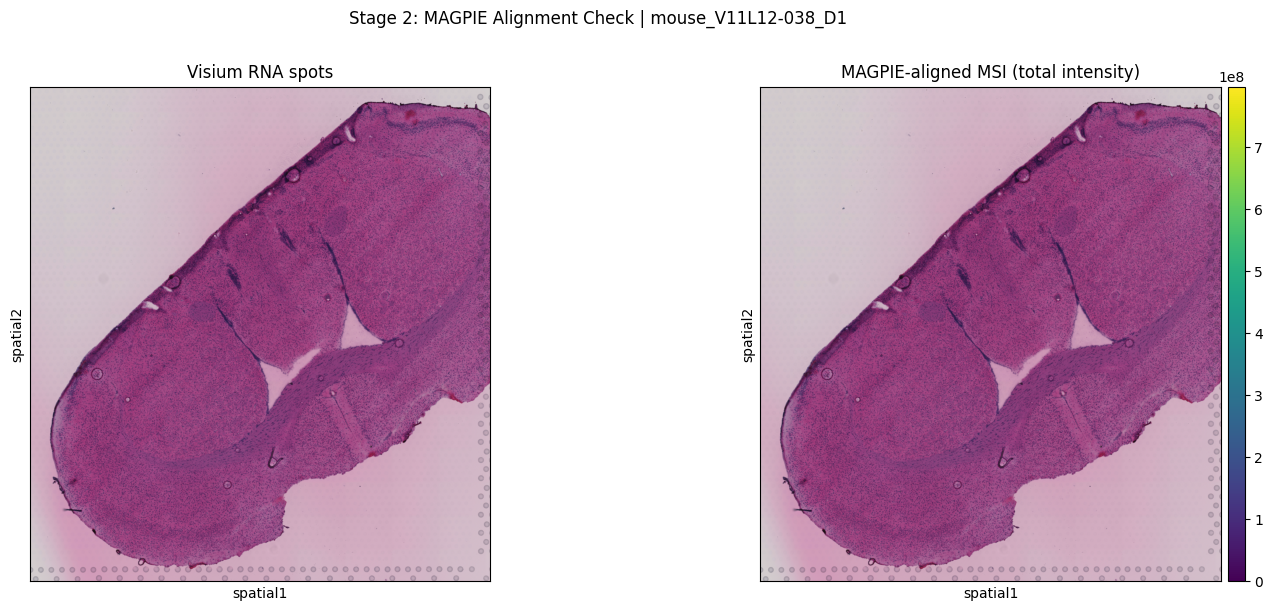

Both tissue shapes should look similar — confirms alignment is good.


In [19]:
# Visual alignment check on main sample
MAIN = 'mouse_V11L12-038_D1'
rna_main = rna_all[MAIN]
msi_main = msi_all[MAIN]

# Total MSI intensity per spot
X_msi_raw = msi_main.X.toarray() if scipy.sparse.issparse(msi_main.X) else np.asarray(msi_main.X)
msi_main.obs['total_msi'] = X_msi_raw.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.spatial(rna_main, color=None,        spot_size=1.5,
              title='Visium RNA spots',     ax=axes[0], show=False)
sc.pl.spatial(msi_main, color='total_msi', spot_size=1.5,
              title='MAGPIE-aligned MSI (total intensity)',
              ax=axes[1], show=False)
plt.suptitle(f'Stage 2: MAGPIE Alignment Check | {MAIN}', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('figures_b/stage2_alignment_check.png', dpi=150, bbox_inches='tight')
plt.show()
print('Both tissue shapes should look similar — confirms alignment is good.')

---
## Preprocessing
RNA and MSI each get their own preprocessing pipeline.
Applied to all 3 samples.

In [20]:
def preprocess_rna(adata):
    """Standard Visium preprocessing: QC, normalize, HVG selection."""
    adata.var['mt'] = adata.var_names.str.lower().str.startswith('mt-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    adata = adata[adata.obs['pct_counts_mt'] < 25].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor='seurat')
    adata = adata[:, adata.var.highly_variable].copy()
    return adata


def preprocess_msi(X):
    """TIC normalize, log transform, variance filter."""
    X = X.astype(np.float32)
    # TIC normalization
    tic = X.sum(axis=1, keepdims=True)
    tic[tic == 0] = 1
    X = X / tic
    # Log transform
    X = np.log1p(X)
    # Remove bottom 25% lowest-variance m/z features
    keep = X.var(axis=0) > np.percentile(X.var(axis=0), 25)
    X = X[:, keep]
    return X, keep

In [21]:
# Preprocess all 3 samples
rna_processed = {}
msi_processed = {}

for s in SAMPLES:
    print(f'Preprocessing {s}...')
    rna = rna_all[s].copy()
    msi = msi_all[s].copy()

    # Preprocess RNA
    rna_pp = preprocess_rna(rna)

    # Align MSI to spots that survived RNA filtering
    common = rna_pp.obs_names.intersection(msi.obs_names)
    msi = msi[common].copy()
    rna_pp = rna_pp[common].copy()

    # Preprocess MSI
    X_msi = msi.X.toarray() if scipy.sparse.issparse(msi.X) else np.asarray(msi.X)
    X_msi_pp, mz_keep = preprocess_msi(X_msi)

    # Store MSI back in AnnData
    rna_pp.obsm['X_msi'] = X_msi_pp
    rna_pp.uns['msi_features'] = msi.var_names[mz_keep].tolist()

    rna_processed[s] = rna_pp
    msi_processed[s] = X_msi_pp

    print(f'  RNA: {rna_pp.shape} | MSI: {X_msi_pp.shape}')

Preprocessing mouse_V11L12-038_B1...
  RNA: (2642, 2000) | MSI: (2642, 2065)
Preprocessing mouse_V11L12-038_D1...
  RNA: (2473, 2000) | MSI: (2473, 2743)
Preprocessing mouse_V11T16-085_C1...
  RNA: (2841, 2000) | MSI: (2841, 1153)


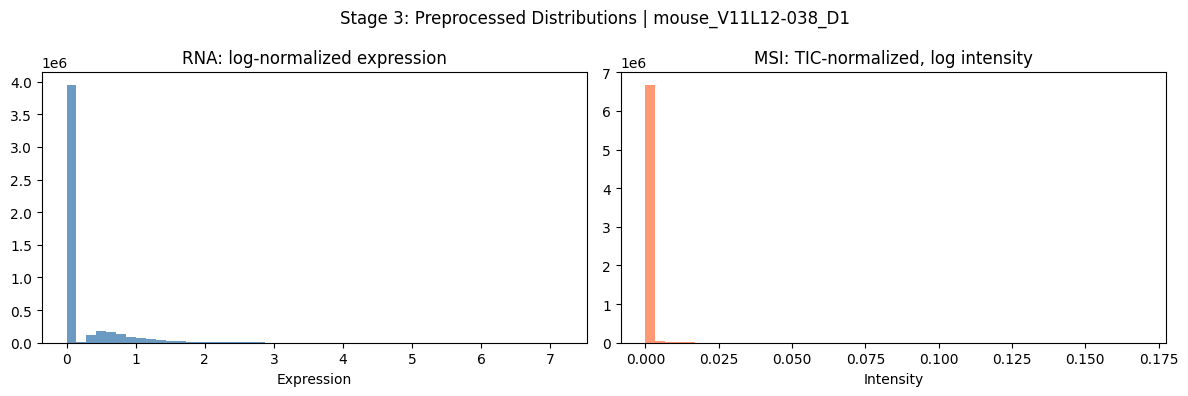

RNA  — shape: (2473, 2000) | min: 0.000 | max: 7.173
MSI  — shape: (2473, 2743) | min: 0.000 | max: 0.169


In [22]:
# Distribution check on main sample
v = rna_processed[MAIN]
X_rna = v.X.toarray() if scipy.sparse.issparse(v.X) else np.asarray(v.X)
X_msi = v.obsm['X_msi']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_rna.flatten(), bins=50, color='steelblue', alpha=0.8)
axes[0].set_title('RNA: log-normalized expression')
axes[0].set_xlabel('Expression')
axes[1].hist(X_msi.flatten(), bins=50, color='coral', alpha=0.8)
axes[1].set_title('MSI: TIC-normalized, log intensity')
axes[1].set_xlabel('Intensity')
plt.suptitle(f'Stage 3: Preprocessed Distributions | {MAIN}', fontsize=12)
plt.tight_layout()
plt.savefig('figures_b/stage3_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'RNA  — shape: {X_rna.shape} | min: {X_rna.min():.3f} | max: {X_rna.max():.3f}')
print(f'MSI  — shape: {X_msi.shape} | min: {X_msi.min():.3f} | max: {X_msi.max():.3f}')

In [26]:
# Save preprocessed data for AE
for s in SAMPLES:
    v_pp = rna_processed[s]
    safe = s.replace('-', '_')
    v_pp.write(f'{safe}_preprocessed.h5ad')
    X_rna = v_pp.X.toarray() if scipy.sparse.issparse(v_pp.X) else np.asarray(v_pp.X)
    np.save(f'{safe}_X_rna.npy', X_rna)
    np.save(f'{safe}_X_msi.npy', v_pp.obsm['X_msi'])
    print(f'Saved: {safe}_preprocessed.h5ad | {safe}_X_rna.npy | {safe}_X_msi.npy')
import zipfile
import glob

files_to_zip = (
    glob.glob('/content/*.h5ad') +
    glob.glob('/content/*.npy') +
    glob.glob('/content/figures_b/*.png')
)

with zipfile.ZipFile('datapreprocessed_output.zip', 'w') as zf:
    for f in files_to_zip:
        zf.write(f, arcname=f.split('/content/')[-1])


print('\n done')

Saved: mouse_V11L12_038_B1_preprocessed.h5ad | mouse_V11L12_038_B1_X_rna.npy | mouse_V11L12_038_B1_X_msi.npy
Saved: mouse_V11L12_038_D1_preprocessed.h5ad | mouse_V11L12_038_D1_X_rna.npy | mouse_V11L12_038_D1_X_msi.npy
Saved: mouse_V11T16_085_C1_preprocessed.h5ad | mouse_V11T16_085_C1_X_rna.npy | mouse_V11T16_085_C1_X_msi.npy

 done
